In [2]:
import jax
jax.config.update('jax_platform_name', 'cpu')
jax.config.update('jax_platforms', 'cpu')
jax.config.update('jax_enable_x64', True)
import jax.numpy as jnp
import numpy as np
from datetime import datetime, timezone
import matplotlib.pyplot as plt
import cmocean as cmo

import atmo3 as a3
from atmo3 import atm_utils as au

import xarray as xr
import pandas as pd


In [3]:
from matplotlib import pyplot as plt
# 1. Update global parameters for presentation visibility
plt.rcParams.update({
    'font.size': 18,              # General font size for text
    'axes.labelsize': 20,         # Size of X and Y axis labels
    'axes.titlesize': 24,         # Size of the graph title
    'xtick.labelsize': 16,        # Size of the numbers on the X axis
    'ytick.labelsize': 16,        # Size of the numbers on the Y axis
    'legend.fontsize': 16,        # Size of the legend text
    'lines.linewidth': 3,       # Thicker lines for the plotted data
})

In [4]:
# Turbulence injection scales: the wavenumber k0 = 2π/L_inj marks the peak
# of the power spectrum, i.e. the scale at which turbulent energy is injected.
q_injection_scale_in_m  = 500.0  # Water-vapour injection scale (m)
ta_injection_scale_in_m = 200.0  # Temperature injection scale (m)

# Grid dimensions [Nx, Ny, Nz] and physical box size [Lx, Ly, Lz] in metres.
# The horizontal resolution is Lx/Nx ≈ 39 m; the vertical is Lz/Nz ≈ 39 m.
nside_grid = [256, 256, 64]
box_length = [3000., 3000., 3000.]

# APEX observatory: altitude 5100 m a.s.l., Llano de Chajnantor, Chile.
site_altitude = 5100.
site_coordinates = [-67.78, -22.95]  # [longitude, latitude] in degrees

# Simulation epoch in UTC.  ERA5 profiles and APEX weather data are
# selected from a ±30-minute window centred on this timestamp.
time_utc = datetime(2023, 9, 3, 23, 0, tzinfo=timezone.utc)

# =============================================================================
# Input data paths
# =============================================================================

atmo3_data = '/pscratch/sd/s/shamikg/atmo3_data/'

# ERA5 pressure-level files covering the APEX region (291–293 °E, 24–22 °S)
# at 0.25° resolution for September 2023.
geopotfile = f'{atmo3_data}era5/2023/geopt.202309.ap1e5.291.0_293.0_-24.0_-22.0_025.nc'
tempfile   = f'{atmo3_data}era5/2023/ta.202309.ap1e5.291.0_293.0_-24.0_-22.0_025.nc'
spechfile  = f'{atmo3_data}era5/2023/q.202309.ap1e5.291.0_293.0_-24.0_-22.0_025.nc'
ccfile     = f'{atmo3_data}era5/2023/cc.202309.ap1e5.291.0_293.0_-24.0_-22.0_025.nc'
ciwcfile   = f'{atmo3_data}era5/2023/ciwc.202309.ap1e5.291.0_293.0_-24.0_-22.0_025.nc'
clwcfile   = f'{atmo3_data}era5/2023/clwc.202309.ap1e5.291.0_293.0_-24.0_-22.0_025.nc'
rhfile     = f'{atmo3_data}era5/2023/r.202309.ap1e5.291.0_293.0_-24.0_-22.0_025.nc'

# APEX weather-station CSV (columns: UT, PWV, Temperature, Humidity,
# Wind_Dir, Wind_Speed) spanning 2006–2025.
apexfile = f'{atmo3_data}apex/meteo_apex_2006_2025.csv'

atmo_box22sep = a3.Atmosphere(
    nside_grid=nside_grid,
    box_length_in_m=box_length,
    site_altitude=site_altitude,
    site_coordinates=site_coordinates,
    time_utc=time_utc,
    geopotential_file_era5=geopotfile,
    temperature_file_era5=tempfile,
    spec_humidity_file_era5=spechfile,
    apex_datafile=apexfile
)


2.526086956521739 0.07649950269801416


In [5]:
k_array = np.arange(4*nside_grid[0]) * jnp.min(atmo_box22sep.grid_wsp.dk)

k0_q  = 2*np.pi / q_injection_scale_in_m   # Water-vapour injection wavenumber (rad/m)
k0_ta = 2*np.pi / ta_injection_scale_in_m  # Temperature injection wavenumber (rad/m)

pofk_q  = ( k0_q**2.  + k_array**2 )**-(11/6)
pofk_ta = ( k0_ta**2. + k_array**2 )**-(11/6)

# Normalise to peak = 1; absolute RMS amplitudes come from calibration.
pofk_q  /= np.max(pofk_q)
pofk_ta /= np.max(pofk_ta)

# Pack into dictionaries expected by add_temperature / add_watervapor.
pspec_q  = {'k': k_array, 'pofk': pofk_q}
pspec_ta = {'k': k_array, 'pofk': pofk_ta}


In [6]:
atmo_box22sep.add_watervapor(pspec_q, seed=42)

atmo_box22sep.generate_realization()

Random field : 11.263270 s
Apply P(k) : 11.456942 s
IRFFT : 0.026518 s
Rescaled field : 0.487478 s


In [7]:
watervapor_3d = atmo_box22sep.components["water vapor"].field + atmo_box22sep.component_mean['water vapor']['f'].reshape(1, 1, -1) # in kg/m^3

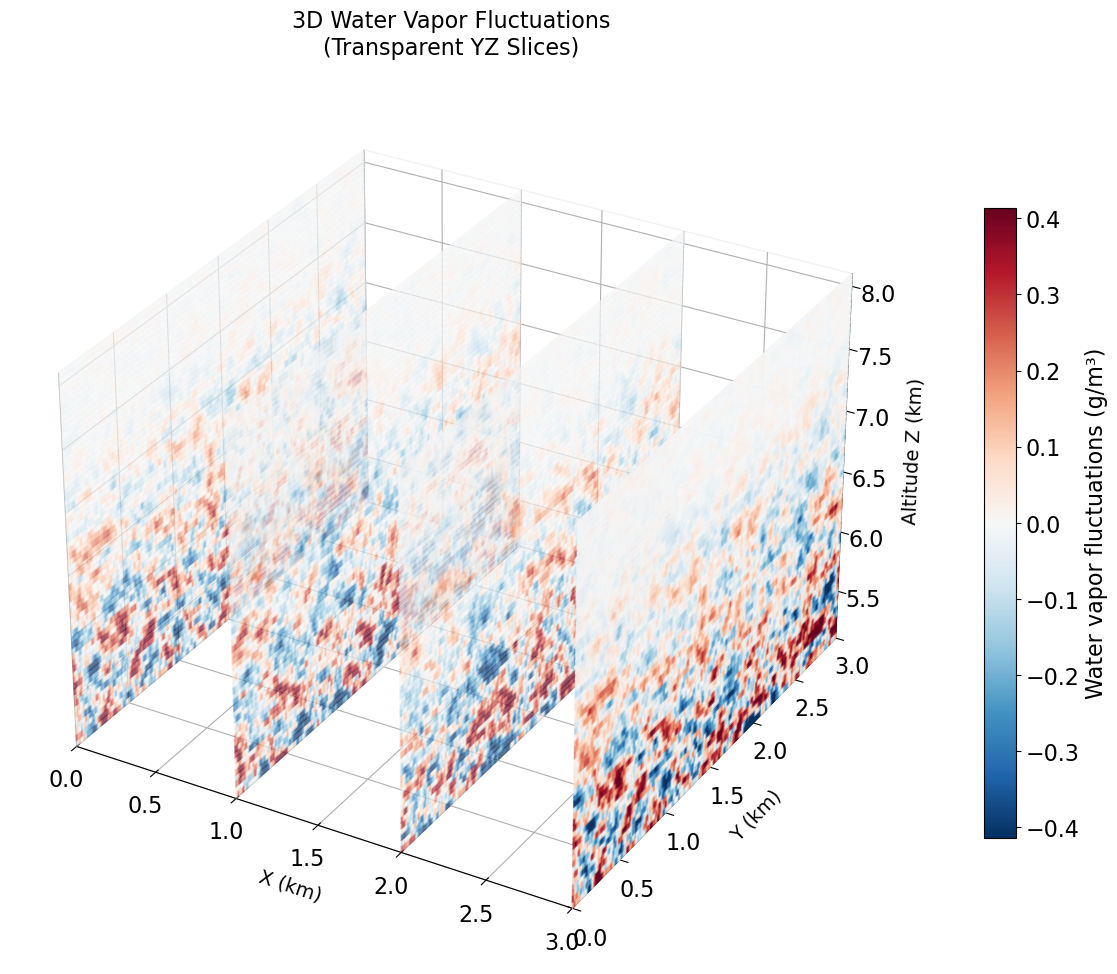

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ==========================================
# --- 1. User Parameters ---
# ==========================================
# Choose the exact X coordinates (in km) where you want to drop a slice
chosen_x_slices_km = [0.0, 1.0, 2.0, 3.0, 4.0, 5.0] 

# Visual parameters
slice_alpha = 0.3    # Transparency of the slices (0.0 to 1.0)
sigma_scale = 3.0    # Color scale bounds (e.g., ±3 standard deviations)

# ==========================================
# --- 2. Extract Data & Prepare Grid ---
# ==========================================
# Extract fluctuations and convert to g/m³ (NO MEAN)
fluctuations_g = atmo_box22sep.components["water vapor"].field * 1e3

# Physical axes (km)
x_edges = np.linspace(0, box_length[0]/1000, nside_grid[0])
y_edges = np.linspace(0, box_length[1]/1000, nside_grid[1])
z_edges = np.linspace(site_altitude/1000, (site_altitude + box_length[2])/1000, nside_grid[2])

# We only need a 2D meshgrid for Y and Z since X will be a constant flat plane for each slice
Y_grid, Z_grid = np.meshgrid(y_edges, z_edges, indexing='ij')

# ==========================================
# --- 3. Define Color Mapping ---
# ==========================================
# Center the diverging colormap strictly at 0 for fluctuations
std_dev = np.std(fluctuations_g)
vmax = sigma_scale * std_dev
vmin = -vmax

norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
cmap = plt.get_cmap('RdBu_r') # Red=Positive (Wet), Blue=Negative (Dry)

# ==========================================
# --- 4. Plotting ---
# ==========================================
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')
ax.set_facecolor('white')

# Loop through your chosen X locations and drop a 2D slice for each
for target_x in chosen_x_slices_km:
    
    # Find the closest grid index to the chosen physical km
    idx_x = (np.abs(x_edges - target_x)).argmin()
    actual_x = x_edges[idx_x]
    
    # Extract the full-resolution 2D YZ slice
    slice_yz = fluctuations_g[idx_x, :, :]
    
    # Create a 2D grid for X filled entirely with the constant actual_x value
    X_grid = np.full_like(Y_grid, actual_x)
    
    # Map the water vapor values to raw RGBA colors
    face_colors = cmap(norm(slice_yz))
    
    # Override the alpha (transparency) channel so we can see through the planes
    face_colors[..., 3] = slice_alpha
    
    # Plot the pane. rstride/cstride = 1 ensures we do not downsample the slice.
    # shade=False prevents Matplotlib from adding fake shadows that ruin the data colors
    ax.plot_surface(X_grid, Y_grid, Z_grid, facecolors=face_colors, shade=False, 
                    rstride=1, cstride=1, antialiased=True)

# ==========================================
# --- 5. Formatting ---
# ==========================================
ax.set_title('3D Water Vapor Fluctuations\n(Transparent YZ Slices)', fontsize=16, pad=20)
ax.set_xlabel('X (km)', fontsize=14, labelpad=10)
ax.set_ylabel('Y (km)', fontsize=14, labelpad=10)
ax.set_zlabel('Altitude Z (km)', fontsize=14, labelpad=10)

# Fix the bounds to represent the entire 20km box, even if slices are only in the middle
ax.set_xlim(x_edges[0], x_edges[-1])
ax.set_ylim(y_edges[0], y_edges[-1])
ax.set_zlim(z_edges[0], z_edges[-1])

# Clean up the panes
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False

# Add a colorbar linked to the normalization we created
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([]) # Required for ScalarMappable
cbar = plt.colorbar(sm, ax=ax, shrink=0.7, pad=0.08)
cbar.set_label('Water vapor fluctuations (g/m³)', fontsize=16)

plt.tight_layout()
plt.show()

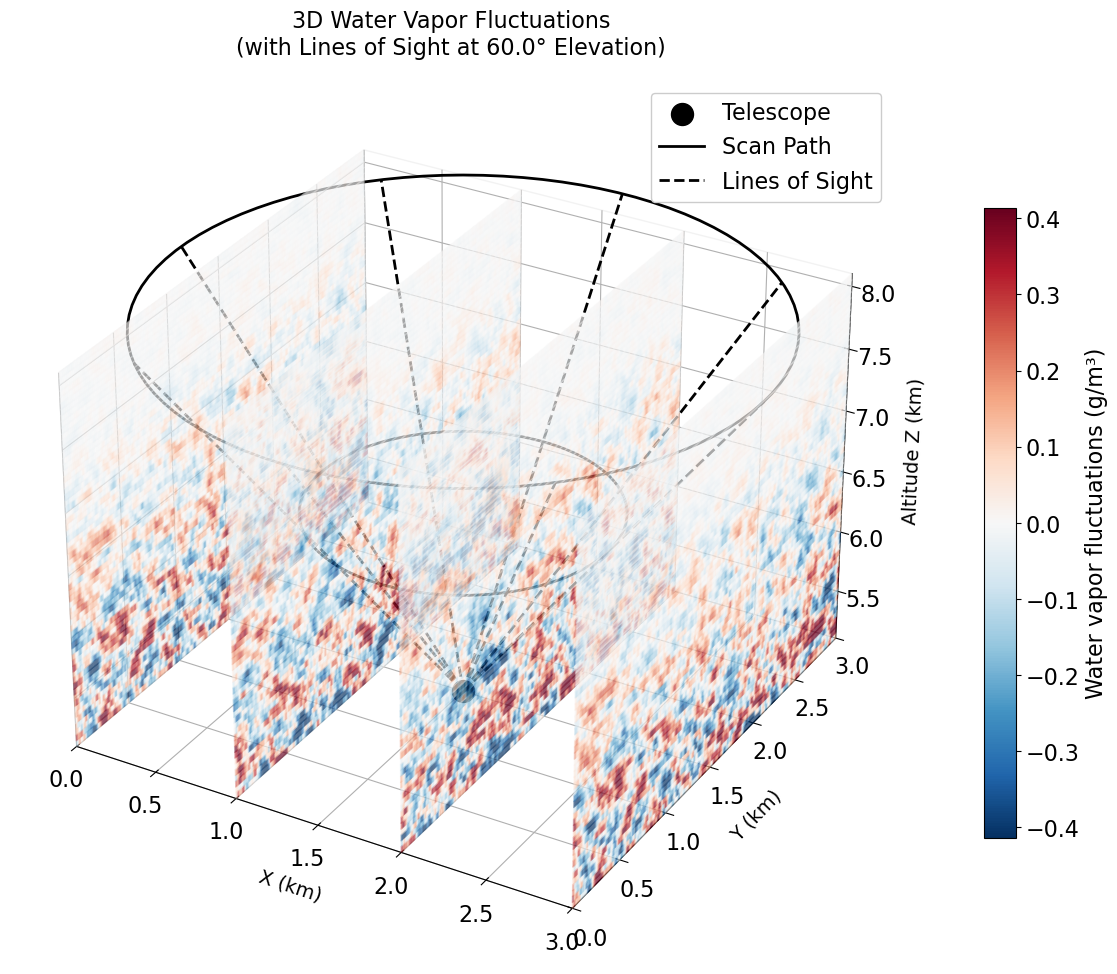

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ==========================================
# --- 1. User Parameters ---
# ==========================================
# Choose the exact X coordinates (in km) where you want to drop a slice
chosen_x_slices_km = [0.0, 1.0, 2.0, 3.0] 

# Visual parameters for the slices
slice_alpha = 0.3    
sigma_scale = 3.0    

# --- NEW: Scan Parameters ---
elevation_angle_deg = 60.0  
scan_color = 'black'         
# Choose which azimuths to explicitly draw lines of sight for (in degrees)
azimuths_deg = [0,45, 90, 135, 180, 225, 270, 315]  # 8 lines of sight for clarity

# ==========================================
# --- 2. Extract Data & Prepare Grid ---
# ==========================================
fluctuations_g = atmo_box22sep.components["water vapor"].field * 1e3

x_edges = np.linspace(0, box_length[0]/1000, nside_grid[0])
y_edges = np.linspace(0, box_length[1]/1000, nside_grid[1])
z_edges = np.linspace(site_altitude/1000, (site_altitude + box_length[2])/1000, nside_grid[2])

Y_grid, Z_grid = np.meshgrid(y_edges, z_edges, indexing='ij')

# ==========================================
# --- 3. Define Color Mapping ---
# ==========================================
std_dev = np.std(fluctuations_g)
vmax = sigma_scale * std_dev
vmin = -vmax

norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
cmap = plt.get_cmap('RdBu_r') 

# ==========================================
# --- 4. Plotting ---
# ==========================================
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')
ax.set_facecolor('white')

# 4A. Plot the Transparent YZ Slices
for target_x in chosen_x_slices_km:
    idx_x = (np.abs(x_edges - target_x)).argmin()
    actual_x = x_edges[idx_x]
    slice_yz = fluctuations_g[idx_x, :, :]
    X_grid = np.full_like(Y_grid, actual_x)
    
    face_colors = cmap(norm(slice_yz))
    face_colors[..., 3] = slice_alpha
    
    ax.plot_surface(X_grid, Y_grid, Z_grid, facecolors=face_colors, shade=False, 
                    rstride=1, cstride=1, antialiased=True)

# 4B. Plot the Telescope Lines of Sight and Scan Ring
center_x = (box_length[0] / 2.0) / 1000.0
center_y = (box_length[1] / 2.0) / 1000.0
center_z = site_altitude / 1000.0
z_top = (site_altitude + box_length[2]) / 1000.0

# Calculate radius at the top of the box
max_radius = (z_top - center_z) / np.tan(np.radians(elevation_angle_deg))

# --- Plot the Telescope Origin ---
ax.scatter([center_x], [center_y], [center_z], color=scan_color, s=250, marker='o', label='Telescope')

# --- Plot the Top Scan Ring ---
theta_circle = np.linspace(0, 2 * np.pi, 100)
circle_x = center_x + max_radius * np.cos(theta_circle)
circle_y = center_y + max_radius * np.sin(theta_circle)
circle_z = np.full_like(theta_circle, z_top )
ax.plot(circle_x, circle_y, circle_z, color=scan_color, linewidth=2, label='Scan Path')

# Plot a ring at the middle of the scan ring for visual clarity
mid_z = center_z + (z_top - center_z) / 2.0
mid_radius = (mid_z - center_z) / np.tan(np.radians(elevation_angle_deg))
mid_circle_x = center_x + mid_radius * np.cos(theta_circle)
mid_circle_y = center_y + mid_radius * np.sin(theta_circle)
mid_circle_z = np.full_like(theta_circle, mid_z)
ax.plot(mid_circle_x, mid_circle_y, mid_circle_z, color=scan_color, linewidth=2)

# --- Plot the Individual Lines of Sight ---
for az in azimuths_deg:
    az_rad = np.radians(az)
    end_x = center_x + max_radius * np.cos(az_rad)
    end_y = center_y + max_radius * np.sin(az_rad)
    
    # Draw a dashed line from the center to the edge of the top ring
    # Only label the first one to avoid duplicate legend entries
    label = 'Lines of Sight' if az == azimuths_deg[0] else ""
    ax.plot([center_x, end_x], [center_y, end_y], [center_z, z_top], 
            color=scan_color, linestyle='--', linewidth=2, label=label)

# ==========================================
# --- 5. Formatting ---
# ==========================================
ax.set_title(f'3D Water Vapor Fluctuations\n(with Lines of Sight at {elevation_angle_deg}° Elevation)', fontsize=16, pad=20)
ax.set_xlabel('X (km)', fontsize=14, labelpad=10)
ax.set_ylabel('Y (km)', fontsize=14, labelpad=10)
ax.set_zlabel('Altitude Z (km)', fontsize=14, labelpad=10)

# Enforce box limits (this automatically clips the scan ring if it exceeds the box size)
ax.set_xlim(x_edges[0], x_edges[-1])
ax.set_ylim(y_edges[0], y_edges[-1])
ax.set_zlim(z_edges[0], z_edges[-1])

ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([]) 
cbar = plt.colorbar(sm, ax=ax, shrink=0.7, pad=0.08)
cbar.set_label('Water vapor fluctuations (g/m³)', fontsize=16)

# Add a legend for the telescope geometry
ax.legend(loc='upper right', framealpha=1.0)

plt.tight_layout()
plt.show()

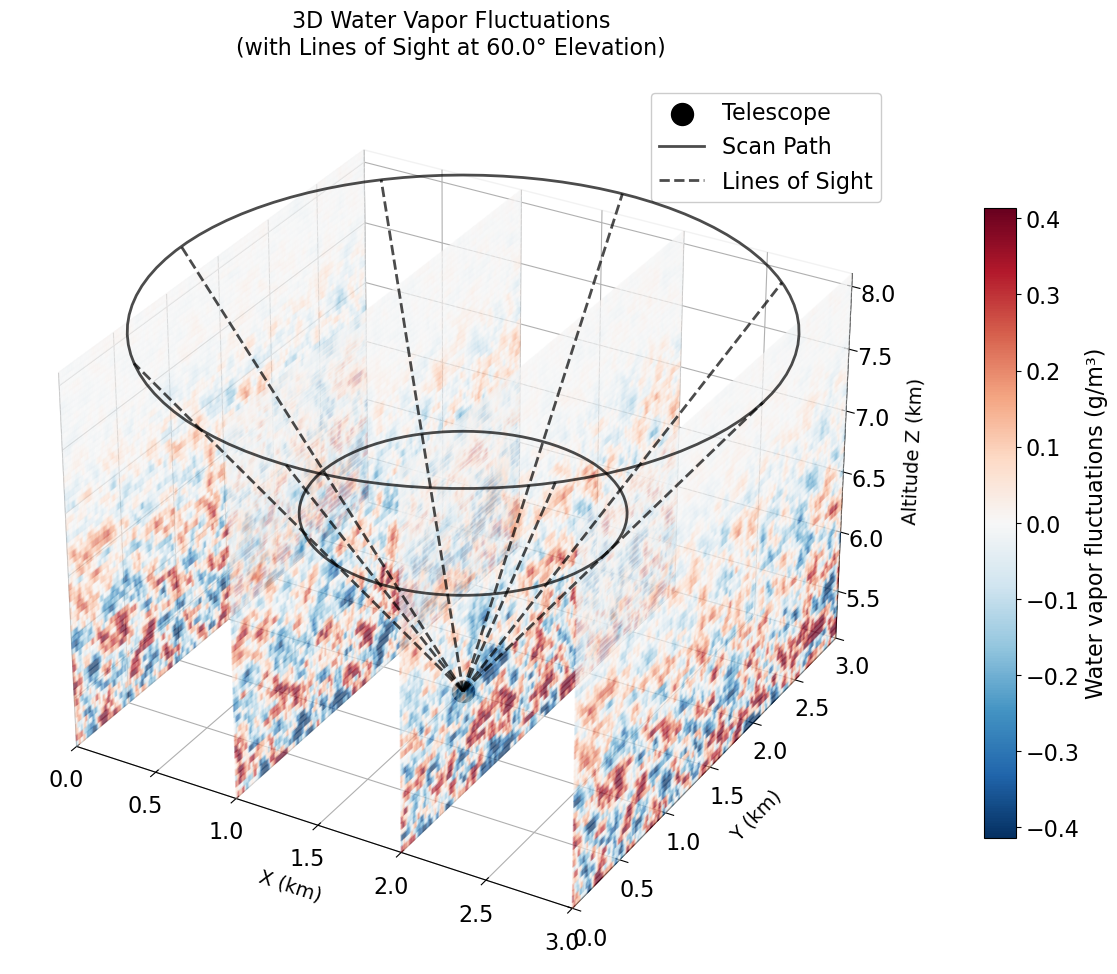

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ==========================================
# --- 1. User Parameters ---
# ==========================================
# Choose the exact X coordinates (in km) where you want to drop a slice
chosen_x_slices_km = [0.0, 1.0, 2.0, 3.0] 

# Visual parameters for the slices
slice_alpha = 0.3    
sigma_scale = 3.0    

# --- NEW: Scan Parameters ---
elevation_angle_deg = 60.0  
scan_color = 'black'         
# Choose which azimuths to explicitly draw lines of sight for (in degrees)
azimuths_deg = [0,45, 90, 135, 180, 225, 270, 315]  # 8 lines of sight for clarity

# ==========================================
# --- 2. Extract Data & Prepare Grid ---
# ==========================================
fluctuations_g = atmo_box22sep.components["water vapor"].field * 1e3

x_edges = np.linspace(0, box_length[0]/1000, nside_grid[0])
y_edges = np.linspace(0, box_length[1]/1000, nside_grid[1])
z_edges = np.linspace(site_altitude/1000, (site_altitude + box_length[2])/1000, nside_grid[2])

Y_grid, Z_grid = np.meshgrid(y_edges, z_edges, indexing='ij')

# ==========================================
# --- 3. Define Color Mapping ---
# ==========================================
std_dev = np.std(fluctuations_g)
vmax = sigma_scale * std_dev
vmin = -vmax

norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
cmap = plt.get_cmap('RdBu_r') 

# ==========================================
# --- 4. Plotting ---
# ==========================================
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')
ax.set_facecolor('white')

# 4A. Plot the Transparent YZ Slices FIRST
for target_x in chosen_x_slices_km:
    idx_x = (np.abs(x_edges - target_x)).argmin()
    actual_x = x_edges[idx_x]
    
    slice_yz = fluctuations_g[idx_x, :, :]
    X_grid = np.full_like(Y_grid, actual_x)
    
    face_colors = cmap(norm(slice_yz))
    face_colors[..., 3] = slice_alpha
    
    # Surfaces have a low zorder (e.g., 1)
    ax.plot_surface(X_grid, Y_grid, Z_grid, facecolors=face_colors, shade=False, 
                    rstride=1, cstride=1, antialiased=True, zorder=1)

# 4B. Plot the Telescope Lines of Sight and Scan Ring LAST with HIGH ZORDER
center_x = (box_length[0] / 2.0) / 1000.0
center_y = (box_length[1] / 2.0) / 1000.0
center_z = site_altitude / 1000.0
z_top = (site_altitude + box_length[2]) / 1000.0

max_radius = (z_top - center_z) / np.tan(np.radians(elevation_angle_deg))

# Draw Telescope point
ax.scatter([center_x], [center_y], [center_z], color=scan_color, s=250, marker='o', zorder=100, label='Telescope')

# Draw Scan Rings (zorder=10 ensures they are on top)
theta_circle = np.linspace(0, 2 * np.pi, 100)
for z_val in [z_top, center_z + (z_top - center_z) / 2.0]:
    radius = (z_val - center_z) / np.tan(np.radians(elevation_angle_deg))
    c_x = center_x + radius * np.cos(theta_circle)
    c_y = center_y + radius * np.sin(theta_circle)
    label = 'Scan Path' if z_val == z_top else ""
    ax.plot(c_x, c_y, np.full_like(theta_circle, z_val), color=scan_color, linewidth=2, zorder=10, label=label, alpha=0.7)

# Draw Lines of Sight
for az in azimuths_deg:
    az_rad = np.radians(az)
    end_x = center_x + max_radius * np.cos(az_rad)
    end_y = center_y + max_radius * np.sin(az_rad)
    label = 'Lines of Sight' if az == azimuths_deg[0] else ""
    ax.plot([center_x, end_x], [center_y, end_y], [center_z, z_top], 
            color=scan_color, linestyle='--', linewidth=2, zorder=10, label=label, alpha=0.7)

# ==========================================
# --- 5. Formatting ---
# ==========================================
ax.set_title(f'3D Water Vapor Fluctuations\n(with Lines of Sight at {elevation_angle_deg}° Elevation)', fontsize=16, pad=20)
ax.set_xlabel('X (km)', fontsize=14, labelpad=10)
ax.set_ylabel('Y (km)', fontsize=14, labelpad=10)
ax.set_zlabel('Altitude Z (km)', fontsize=14, labelpad=10)

# Enforce box limits (this automatically clips the scan ring if it exceeds the box size)
ax.set_xlim(x_edges[0], x_edges[-1])
ax.set_ylim(y_edges[0], y_edges[-1])
ax.set_zlim(z_edges[0], z_edges[-1])

ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([]) 
cbar = plt.colorbar(sm, ax=ax, shrink=0.7, pad=0.08)
cbar.set_label('Water vapor fluctuations (g/m³)', fontsize=16)

# Add a legend for the telescope geometry
ax.legend(loc='upper right', framealpha=1.0)

plt.tight_layout()
plt.show()

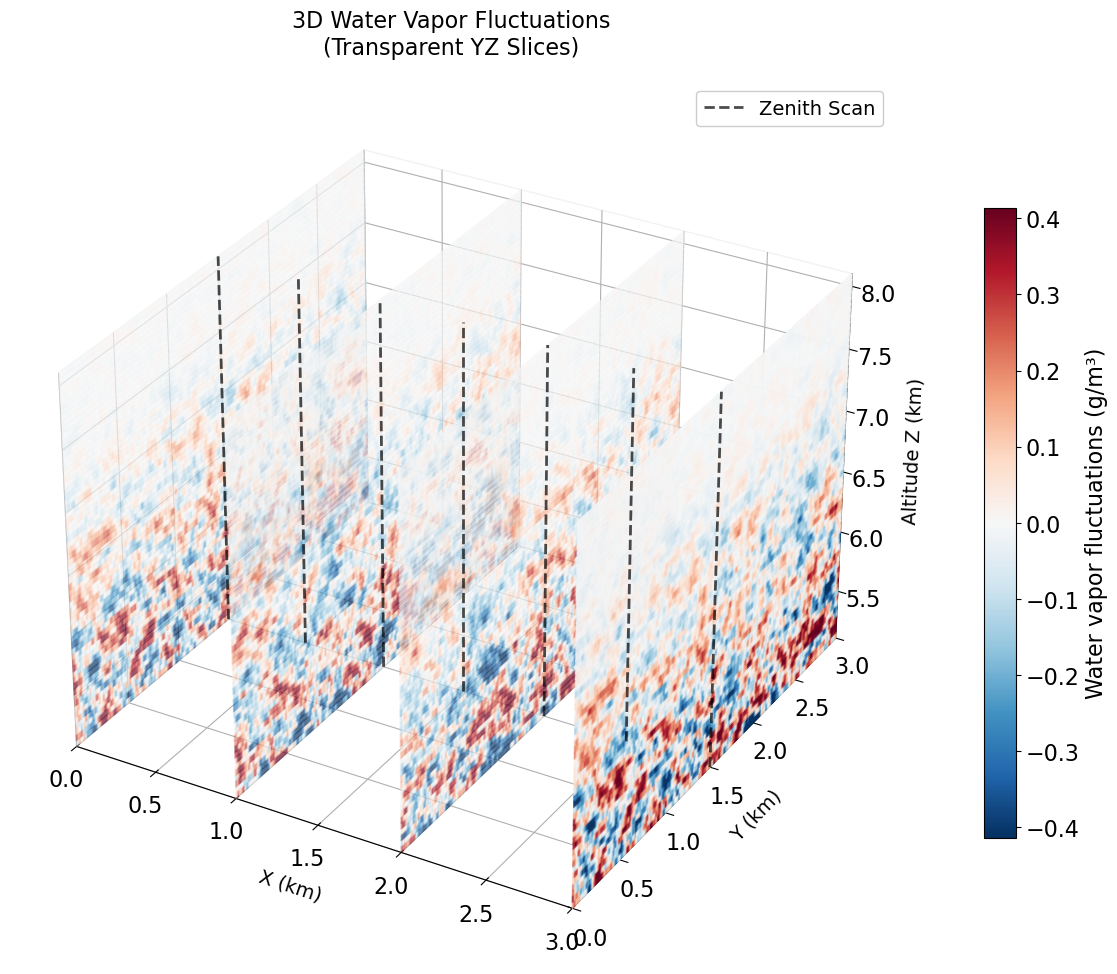

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ==========================================
# --- 1. User Parameters ---
# ==========================================
# Choose the exact X coordinates (in km) where you want to drop a slice
chosen_x_slices_km = [0.0, 1.0, 2.0, 3.0, 4.0, 5.0]

# Visual parameters
slice_alpha = 0.3    # Transparency of the slices (0.0 to 1.0)
sigma_scale = 3.0    # Color scale bounds (e.g., ±3 standard deviations)

# Zenithal scan lines of sight (vertical lines along z)
zenith_x_positions_km = [0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0]

# ==========================================
# --- 2. Extract Data & Prepare Grid ---
# ==========================================
# Extract fluctuations and convert to g/m^3 (NO MEAN)
fluctuations_g = atmo_box22sep.components["water vapor"].field * 1e3

# Physical axes (km)
x_edges = np.linspace(0, box_length[0]/1000, nside_grid[0])
y_edges = np.linspace(0, box_length[1]/1000, nside_grid[1])
z_edges = np.linspace(site_altitude/1000, (site_altitude + box_length[2])/1000, nside_grid[2])

# We only need a 2D meshgrid for Y and Z since X will be a constant flat plane for each slice
Y_grid, Z_grid = np.meshgrid(y_edges, z_edges, indexing='ij')

# ==========================================
# --- 3. Define Color Mapping ---
# ==========================================
# Center the diverging colormap strictly at 0 for fluctuations
std_dev = np.std(fluctuations_g)
vmax = sigma_scale * std_dev
vmin = -vmax

norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
cmap = plt.get_cmap('RdBu_r') # Red=Positive (Wet), Blue=Negative (Dry)

# ==========================================
# --- 4. Plotting ---
# ==========================================
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')
ax.set_facecolor('white')

# Loop through your chosen X locations and drop a 2D slice for each
for target_x in chosen_x_slices_km:

    # Find the closest grid index to the chosen physical km
    idx_x = (np.abs(x_edges - target_x)).argmin()
    actual_x = x_edges[idx_x]

    # Extract the full-resolution 2D YZ slice
    slice_yz = fluctuations_g[idx_x, :, :]

    # Create a 2D grid for X filled entirely with the constant actual_x value
    X_grid = np.full_like(Y_grid, actual_x)

    # Map the water vapor values to raw RGBA colors
    face_colors = cmap(norm(slice_yz))

    # Override the alpha (transparency) channel so we can see through the planes
    face_colors[..., 3] = slice_alpha

    # Plot the pane. rstride/cstride = 1 ensures we do not downsample the slice.
    # shade=False prevents Matplotlib from adding fake shadows that ruin the data colors
    ax.plot_surface(X_grid, Y_grid, Z_grid, facecolors=face_colors, shade=False,
                    rstride=1, cstride=1, antialiased=True)

# Add zenithal scan lines at fixed y = box_length[0]/1000/2 and chosen x positions
scan_y_km = box_length[0] / 1000 / 2
for x_scan in zenith_x_positions_km:
    x_scan_clipped = np.clip(x_scan, x_edges[0], x_edges[-1])
    ax.plot([x_scan_clipped, x_scan_clipped],
            [scan_y_km, scan_y_km],
            [z_edges[0], z_edges[-1]],
            color='black', linewidth=2, linestyle='--', zorder=10, alpha=0.7, label='Zenith Scan' if x_scan == zenith_x_positions_km[0] else "")

# ==========================================
# --- 5. Formatting ---
# ==========================================
ax.set_title('3D Water Vapor Fluctuations\n(Transparent YZ Slices)', fontsize=16, pad=20)
ax.set_xlabel('X (km)', fontsize=14, labelpad=10)
ax.set_ylabel('Y (km)', fontsize=14, labelpad=10)
ax.set_zlabel('Altitude Z (km)', fontsize=14, labelpad=10)


# Fix the bounds to represent the entire 20km box, even if slices are only in the middle
ax.set_xlim(x_edges[0], x_edges[-1])
ax.set_ylim(y_edges[0], y_edges[-1])
ax.set_zlim(z_edges[0], z_edges[-1])

# Clean up the panes
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False

# Add a colorbar linked to the normalization we created
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([]) # Required for ScalarMappable
cbar = plt.colorbar(sm, ax=ax, shrink=0.7, pad=0.08)
cbar.set_label('Water vapor fluctuations (g/m³)', fontsize=16)
ax.legend(loc='upper right', framealpha=1.0, fontsize=14)

plt.tight_layout()
plt.show()